# Übung 12

**Gruppenname:**

*Name Ihrer Gruppe*

Gehen Sie wie folgt vor:

1. Kopieren Sie jetzt dieses Jupyter Notebook in Ihren Ordner (`Abgaben/Team_WXYZ`)

2. Tragen Sie Ihren Gruppennamen auch ganz oben bei "Name Ihrer Gruppe" ein.

3. Bearbeiten Sie dann dieses Notebook. Falls Sie das Notebook im Browser bearbeiten, vergessen Sie nicht, es regelmäßig zu speichern (z.B. über `Strg + S` oder über `File -> Save and Checkpoint`).

### In dieser Übung ...

... werden wir uns mit daten-getriebener Modellierung mithilfe von $k$-Nächste Nachbarn Modellen beschäftigen. $k$-Nächste Nachbarn Modelle gehören zu den einfachsten Machine Learning Modellen. Viele weitere Modelle können Sie im Bachelor Kurs "Machine Learning" kennenlernen.

###  (Optional) 12.1 Weinqualitäten (Multiklassen-Klassifikation, Feature Engineering)

* Diese Übung kennen Sie in abgewandelter Form aus der optionalen Übung 11.3. Falls Sie Übung 11.3 schon bearbeitet haben, können Sie sich von dort für eine Lösung hier inspirieren lassen.

In dieser Übung werden wir ein $k$-Nächste Nachbarn (kNN) Modell erstellen, mit dem wir die Klasse eines Weines (d.h. die Kultursorte) aus den Eigenschaften vorhersagen können. Wir werden mit PCA-transformierten Merkmalen arbeiten.

**Ihre Daten**

Zu Beginn der 90er Jahre wurden verschiedene Weinproben in einer Region Italiens untersucht. Die Weine stammen von drei verschiedenen Kultursorten. Diese Kultursorten werden im unten hinterlegten Datensatz als Klasse 1, 2 und 3 (*class labels*) bezeichnet. Unter den 13 untersuchten Merkmalen finden Sie neben chemischen Eigenschaften (Alkoholgehalt, Säuregehalt) auch physikalische Eigenschaften (Farbintensität, etc).

Der Weindatensatz wird in zwei Teile geteilt: Trainings- und Testdaten.

In [21]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import zscore
from sklearn.model_selection import train_test_split

# import data
column_names = ['Class label', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanoids', 
                'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 'Hue', 'OD280/OD315 of diluted wines', 'Proline']
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)
df.columns = column_names

# preprocess data
X, y = df.iloc[:, 1:].values, df.iloc[:, 0].values

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.4, random_state=10)

# apply PCA
pca = PCA(n_components=2)
X_train_p = pca.fit_transform(X_train)
X_test_p = pca.transform(X_test)


**Ihre Aufgaben**

(1) Importieren Sie die Daten, indem Sie die obere Code-Zelle ausführen.

In [22]:
#OBEN

(2) Vergegenwärtigen Sie sich die Eigenschaften des Wein-Datensatzes: Untersuchen Sie dazu das Pandas-Objekt. Welche Eigenschaften wurden für die Weine erfasst? Wie viele Weinproben wurden genommen?

In [23]:
n_samples, m_feature = X.shape
cols = df.columns

df

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


(3) Lesen Sie den Code ab dem Kommentar `# preprocess data`. Was passiert in diesen Code-Zeilen? Welches Feature-Engineering findet statt, bis wir zu den Daten `X_train_p, X_test_p` angekommen sind, mit denen Sie dann arbeiten werden? Wie viele Features (Merkmale) haben die transformierten Daten?

In [24]:
# Removing labels and preparing the data by stpliting it into features and labels. The it gets splitted again for training and 
# test data.

(4) Visualisieren Sie in zwei Scatterplots den PCA-transformierten Trainingsdatensatz sowie den Testdatensatz. Färben Sie die Punkte in beiden Plots ein gemäß der Klassenzugehörigkeit, wie Sie in Ihrem Vektor `y_train` bzw. `y_test` kodiert ist. Die Einträge in `y_train` und `y_test` werden auch *Labels* genannt.
* Hinweis: Vielleicht wollen Sie sich an Ihrem Code aus früheren Übungen bedienen, wo Sie eine ähnliche Aufgabe schon einmal gelöst haben.

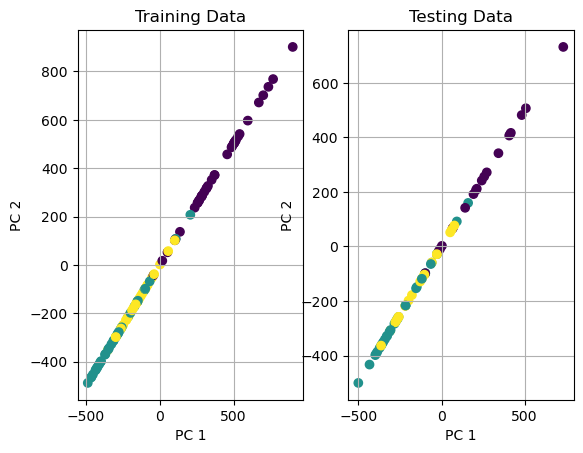

In [25]:
fig, ax = plt.subplots(1, 2)

ax[0].scatter(X_train_p[:, 0], X_train_p[:, 0], c=y_train)
ax[0].set_title("Training Data")
ax[0].set_xlabel("PC 1")
ax[0].set_ylabel("PC 2")
ax[0].grid(True)


ax[1].scatter(X_test_p[:, 0], X_test_p[:, 0], c=y_test)
ax[1].set_title("Testing Data")
ax[1].set_xlabel("PC 1")
ax[1].set_ylabel("PC 2")
ax[1].grid(True)

(5) Wir werden jetzt ein $k$NN-Modell für $k=1$ erstellen. Schreiben Sie dazu eine Funktion mit dem Namen `NN`, die die Trainingsdaten (`X_train_p` und `y_train`) sowie die Testdaten (`X_test_p`) entgegennimmt und die vorhergesagten Klassen (Labels) für die Testdaten als Vektor (`y_pred`) zurückgibt. Nutzen Sie für die Implementierung NumPy Funktionen. Broadcasting kann ebenfalls hilfreich sein.  

In [26]:
from collections import Counter

class KNN:
    def __init__(self, k=5) -> None:
        self.k = k
    
    def fit(self, X_train, y_train):
        self.X_train = X_train
        self.y_train = y_train
        self.n_samples, self.m_features = X_train.shape
    
    def predict(self, X_test):
        return np.array([self._majority_vote(x) for x in X_test])
    
    def _majority_vote(self, x):
        dists = np.array([np.linalg.norm(x - y) for y in self.X_train])
        idxs = np.argsort(dists)[1:self.k + 1]
        k_nearest = Counter(self.y_train[idxs]).most_common(1)[0][0]
        return k_nearest

knn = KNN(1)
knn.fit(X_train_p, y_train)
y_pred = knn.predict(X_test_p)


(6) Sie haben in Schritt (5) ein einfaches Machine Learning Modell implementiert, einen Klassifikator. Sagen Sie mithilfe Ihrer Funktion die Labels (Klassen) der Weinproben des Testdatensatzes voraus und speichern Sie die Voraussage im Vektor `y_pred`.

In [27]:
#OBEN

(7) Bestimmen Sie die *Accuracy* Ihrer Vorhersage, also den Anteil der korrekt vorhergesagten Klassen dividiert durch die Gesamtanzahl aller Vorhersagen. Beurteilen Sie anhand der *Accuracy*, ob Ihr Modell die Klassen des Testdatensatzes gut vorhersagen kann. 

In [28]:
def acc(y_pred, y_test):
    return np.sum([y_pred[i] == y_test[i] for i in range(len(y_pred))])/len(y_pred)

accu = acc(y_pred, y_test)

(8) Wiederholen Sie Schritt (5), allerdings für Trainingsdaten, deren Features Sie auf Mittelwert $0$ und Varianz $1$ normiert haben:

- Berechnen Sie Mittelwerte und Standardabweichungen der Features der Trainingsdaten **vor der PCA**. Normieren Sie die Trainingsdaten anschließend mit den berechneten Werten. Führen Sie dann die PCA mit den normierten Daten durch und klassifizieren Sie die aus der PCA resultierenden Daten. Welche Genauigkeit (Accuracy) erhalten Sie nun auf den Trainingsdaten? Wie erklären Sie sich diese Veränderung im Vergleich zu dem Ergebnis aus Schritt (7)?

- Normieren Sie anschließend auch die Testdaten, und zwar so, dass diese mit denselben Parametern wie die Trainingsdaten normiert werden, d.h. basierend auf Mittelwerten und Standardabweichungen der **Trainingsdaten**.

- Warum ist es wichtig, dass die Testdaten mit denselben Parametern normiert werden wie die Trainingsdaten?

In [29]:
def normalize(X):
    return (X - np.mean(X))/np.std(X) 

X_train = normalize(X_train)
X_test = normalize(X_test)

X_train_p = pca.fit_transform(X_train)
X_test = pca.fit_transform(X_test)

knn.fit(X_train_p, y_train)
y_pred = knn.predict(X_test_p)

acc(y_pred, y_test)

np.float64(0.6666666666666666)

(9) Wir werden nun untersuchen, wie sich die *Accuracy* mit der Anzahl $k$ der nächsten Nachbarn ändert. Nutzen Sie die [Implementierung des kNN Modells von scikit learn](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html), um die Accuracy als Funktion von $k$ zu ermitteln ($k\in\{1, \ldots, 50\}$).

**Hinweise**

* Trainieren Sie Ihr Modell mit den Trainingsdaten.
* Ermitteln Sie die Accuracies mit den Testdaten. 

In [31]:
from sklearn.neighbors import KNeighborsClassifier

def test_knn(limit):
    accs = np.empty(limit)
    for i in range(1, limit + 1):
        knn = KNeighborsClassifier(i)
        knn.fit(X_train_p, y_train)
        y_pred = knn.predict(X_test)
        accs[i - 1] = acc(y_pred, y_test)
    return accs

accs = test_knn(50)
max_idx = np.argmax(accs)
print(f"Maximal accuracy for {max_idx} neighbors: {accs[max_idx]}")

Maximal accuracy for 37 neighbors: 0.6805555555555556


(10) Visualisieren Sie die Accuracy als Funktion von $k$. Bestimmen Sie den besten Wert $k$.

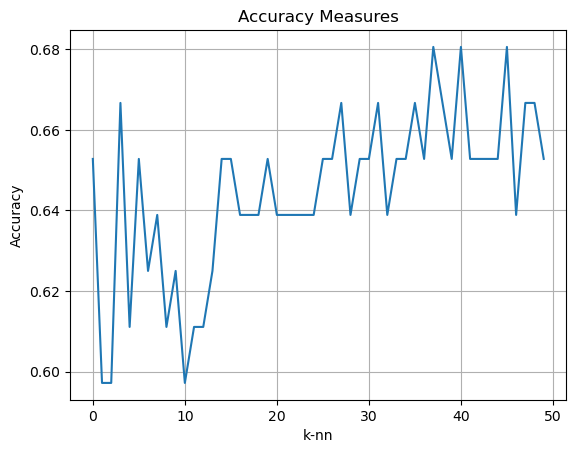

In [33]:
plt.plot(np.arange(50), accs)
plt.title("Accuracy Measures")
plt.xlabel("k-nn")
plt.ylabel("Accuracy")
plt.grid(True)

Herzlichen Glückwunsch! Sie haben ein $k$-Nächste Nachbarn Modell an einen Datensatz angepasst.

### 12.2 k-nächste-Nachbarn Klassifikation
In dieser kurzen Übungsaufgabe werden Sie sich weiter mit dem kNN-Klassifikator vertraut machen und die Wirkung des Parameters $k$ untersuchen.

**Ihre Aufgaben**

(1) Visualisieren Sie die weiter unten erzeugten synthetischen Daten.

(2) Fitten Sie einen [kNN-Klassifikator](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) an die Daten mit $k=1$ und visualisieren Sie mit der Hilfsfunktion `plot_decision_regions` die entstandenen Entscheidungsflächen.

(3) Wiederholen Sie Schritt (2) für einige wenige Werte von $k$. Variieren Sie dabei $k$ zwischen $1$ und $50$. Wie verändern sich die Entscheidungsflächen?

(4) Machen Sie Ihre Visualisierung aus Schritt (3) interaktiv, indem Sie [ipywidgets](https://ipywidgets.readthedocs.io/en/latest/) benutzen, und über einen Slider Werte für $k$ auswählen können.

In [34]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import make_classification
from sklearn.neighbors import KNeighborsClassifier
%matplotlib inline

# helper function to plot decision boundaries
def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=np.expand_dims(cmap(idx), 0),
                    marker=markers[idx], label=cl)


# generate 100 data points: features X, labels y
X, y = make_classification(n_features=2, n_redundant=0, n_informative=1,
                           n_clusters_per_class=1, class_sep=0.5, random_state=2)


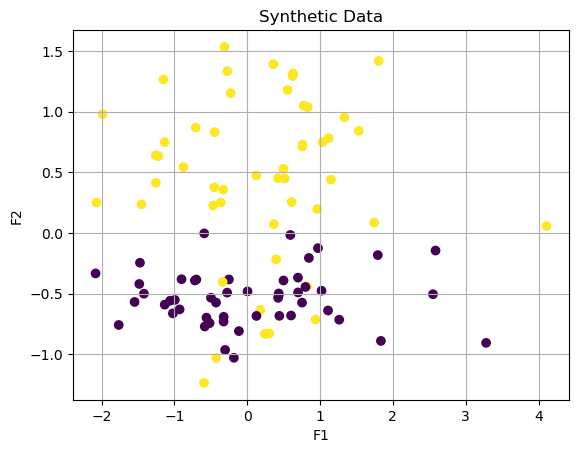

In [ ]:
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Synthetic Data")
plt.xlabel("F1")
plt.ylabel("F2")
plt.grid(True)

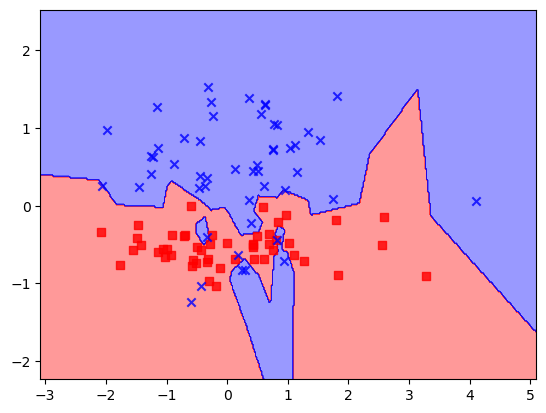

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

knn = KNeighborsClassifier(1)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

plot_decision_regions(X, y, knn)


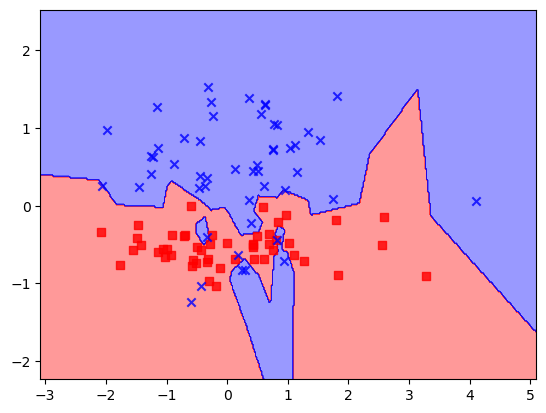

In [53]:
knn = KNeighborsClassifier(1)
knn.fit(X_train, y_train)
plot_decision_regions(X, y, knn)